# LaBr3(Ce) (CH0)

In [239]:
import sympy as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from scipy.signal import find_peaks
from scipy.stats import chi2

---

# load data and get time

### background

In [240]:
bg = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_background\Energy_ch0.txt", skiprows=1)
channelsbg = bg[:, 0]
countsbg = bg[:, 1]
bgtime = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_background\Timestamp_ch0.txt", skiprows=1)
time = bgtime[:, 0]
t_bg = (time[-1] - time[0])* 1e-12

### Am241

In [241]:
am241 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Am241\Energy_ch0.txt", skiprows=1)
channelsam241 = am241[:, 0]
countsam241 = am241[:, 1]
am241time = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Am241\Timestamp_ch0.txt", skiprows=1)
time241 = am241time[:, 0]
t_am241 = (time241[-1] - time241[0])* 1e-12

### Co60

In [242]:
co60 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Co_60\Energy_ch0.txt", skiprows=1)
channelsco60 = co60[:, 0]
countsco60 = co60[:, 1]
co60time = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Co_60\Timestamp_ch0.txt", skiprows=1)
time60 = co60time[:, 0]
t_co60 = (time60[-1] - time60[0])* 1e-12

### Cs137

In [243]:
cs137 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Cs137\Energy_ch0.txt", skiprows=1)
channelscs137 = cs137[:, 0]
countscs137 = cs137[:, 1]
cs137time = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Cs137\Timestamp_ch0.txt", skiprows=1)
time137 = cs137time[:, 0]
t_cs137 = (time137[-1] - time137[0])* 1e-12

### Eu152

In [244]:
eu152 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Eu152\Energy_ch0.txt", skiprows=1)
channelseu152 = eu152[:, 0]
countseu152 = eu152[:, 1]
eu152time = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Eu152\Timestamp_ch0.txt", skiprows=1)
time152 = eu152time[:, 0]
t_eu152 = (time152[-1] - time152[0])* 1e-12

### Na22

In [245]:
na22 = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Na22\Energy_ch0.txt", skiprows=1)
channelsna22 = na22[:, 0]
countsna22 = na22[:, 1]
na22time = np.loadtxt(r"C:\Users\linde\Downloads\IRDNI_PET\measurements_2ndSEM\04_03_Na22\Timestamp_ch0.txt", skiprows=1)
time22 = na22time[:, 0]
t_na22 = (time22[-1] - time22[0])* 1e-12

---

# subtract background

### background

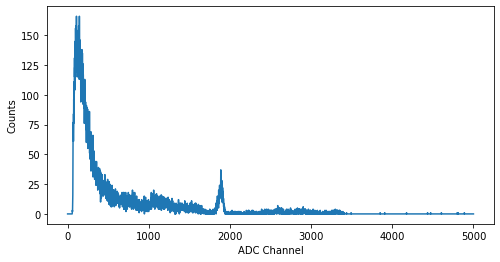

In [246]:
#spectrum background
range_ = (channelsbg > 0) & (channelsbg < 5000)
plt.figure(figsize=(8, 4))
plt.plot(channelsbg[range_], countsbg[range_])
plt.xlabel("ADC Channel")
plt.ylabel("Counts")
plt.show()

### Am241

In [247]:
counts_bg_am241 = countsbg * (t_am241 / t_bg)
netcountsam241 = countsam241 - counts_bg_am241
netcountsam241[netcountsam241 < 0] = 0

In [248]:
range_am241 = (channelsam241 > 0) & (channelsam241 < 2000)

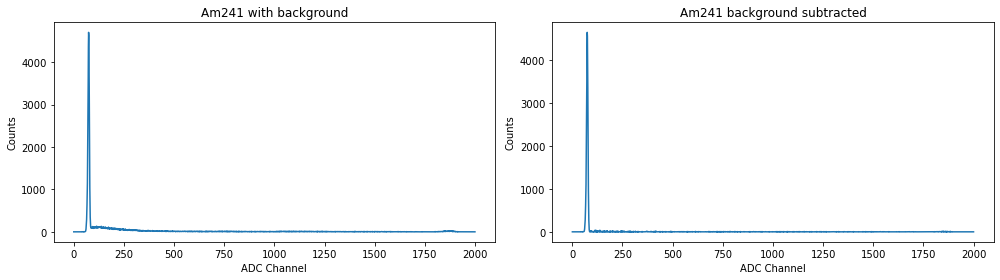

In [249]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns

ax[0].plot(channelsam241[range_am241], countsam241[range_am241])
ax[0].set_title("Am241 with background")
ax[0].set_xlabel("ADC Channel")
ax[0].set_ylabel("Counts")

ax[1].plot(channelsam241[range_am241], netcountsam241[range_am241])
ax[1].set_title("Am241 background subtracted")
ax[1].set_xlabel("ADC Channel")
ax[1].set_ylabel("Counts")

plt.tight_layout()
plt.show()

### Co60

In [250]:
counts_bg_co60 = countsbg * (t_co60 / t_bg)
netcountsco60 = countsco60 - counts_bg_co60
netcountsco60[netcountsco60 < 0] = 0

In [251]:
range_co60 = (channelsco60 > 0) & (channelsco60 < 2000)

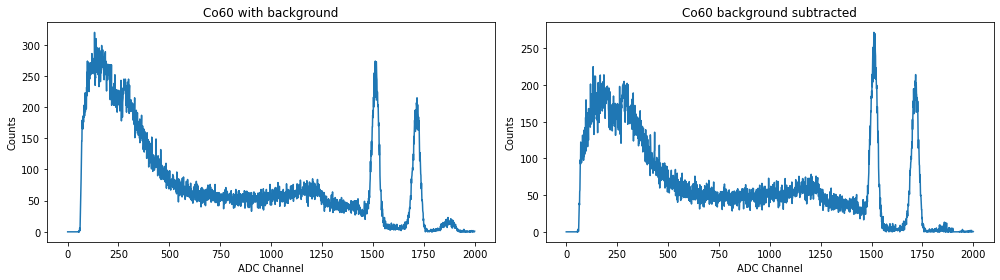

In [252]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns

ax[0].plot(channelsco60[range_co60], countsco60[range_co60])
ax[0].set_title("Co60 with background")
ax[0].set_xlabel("ADC Channel")
ax[0].set_ylabel("Counts")

ax[1].plot(channelsco60[range_co60], netcountsco60[range_co60])
ax[1].set_title("Co60 background subtracted")
ax[1].set_xlabel("ADC Channel")
ax[1].set_ylabel("Counts")

plt.tight_layout()
plt.show()

### Cs137

In [253]:
counts_bg_cs137 = countsbg * (t_cs137 / t_bg)
netcountscs137 = countscs137 - counts_bg_cs137
netcountscs137[netcountscs137 < 0] = 0

In [254]:
range_cs137 = (channelscs137 > 0) & (channelscs137 < 2000)

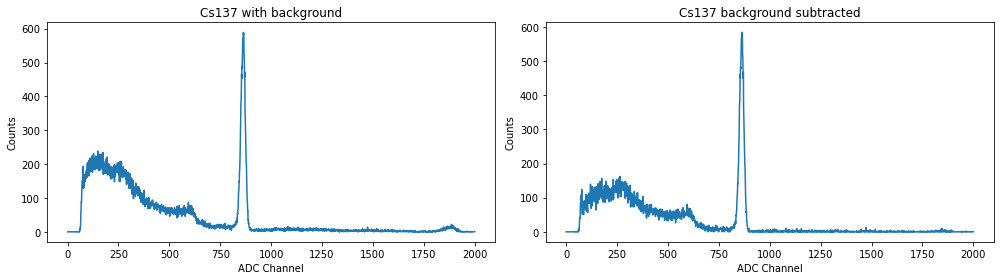

In [255]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns

ax[0].plot(channelscs137[range_cs137], countscs137[range_cs137])
ax[0].set_title("Cs137 with background")
ax[0].set_xlabel("ADC Channel")
ax[0].set_ylabel("Counts")

ax[1].plot(channelscs137[range_cs137], netcountscs137[range_cs137])
ax[1].set_title("Cs137 background subtracted")
ax[1].set_xlabel("ADC Channel")
ax[1].set_ylabel("Counts")

plt.tight_layout()
plt.show()

### Eu152

In [256]:
counts_bg_eu152 = countsbg * (t_eu152 / t_bg)
netcountseu152 = countseu152 - counts_bg_eu152
netcountseu152[netcountseu152 < 0] = 0

In [257]:
range_eu152 = (channelseu152 > 0) & (channelseu152 < 2000)

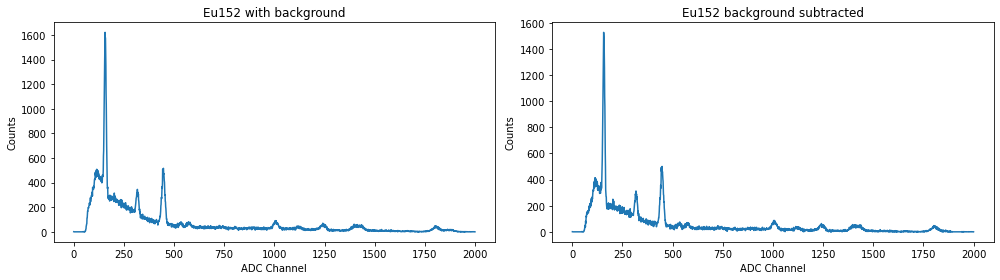

In [258]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns

ax[0].plot(channelseu152[range_eu152], countseu152[range_eu152])
ax[0].set_title("Eu152 with background")
ax[0].set_xlabel("ADC Channel")
ax[0].set_ylabel("Counts")

ax[1].plot(channelseu152[range_eu152], netcountseu152[range_eu152])
ax[1].set_title("Eu152 background subtracted")
ax[1].set_xlabel("ADC Channel")
ax[1].set_ylabel("Counts")

plt.tight_layout()
plt.show()

### Na22

In [259]:
counts_bg_na22 = countsbg * (t_na22 / t_bg)
netcountsna22 = countsna22 - counts_bg_na22
netcountsna22[netcountsna22 < 0] = 0

In [260]:
range_na22 = (channelsna22 > 0) & (channelsna22 < 2000)

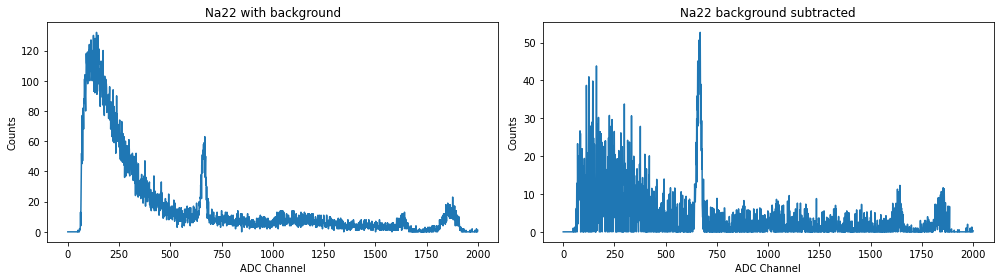

In [261]:
fig, ax = plt.subplots(1, 2, figsize=(14,4))  # 1 row, 2 columns

ax[0].plot(channelsna22[range_na22], countsna22[range_na22])
ax[0].set_title("Na22 with background")
ax[0].set_xlabel("ADC Channel")
ax[0].set_ylabel("Counts")

ax[1].plot(channelsna22[range_na22], netcountsna22[range_na22])
ax[1].set_title("Na22 background subtracted")
ax[1].set_xlabel("ADC Channel")
ax[1].set_ylabel("Counts")

plt.tight_layout()
plt.show()

---

# Statistical errors

counting experiments -> Poisson statistics (sigma_i = sqrt(#counts_i)) 

### Am241

In [262]:
sigma_countsam241 = np.sqrt(countsam241 + (t_am241/t_bg)**2 * countsbg)
sigma_countsam241[sigma_countsam241 == 0] = 1

### Co60

In [263]:
sigma_countsco60 = np.sqrt(countsco60 + (t_co60/t_bg)**2 * countsbg)
sigma_countsco60[sigma_countsco60 == 0] = 1

### Cs137

In [264]:
sigma_countscs137 = np.sqrt(countscs137 + (t_cs137/t_bg)**2 * countsbg)
sigma_countscs137[sigma_countscs137 == 0] = 1

### Eu152

In [265]:
sigma_countseu152 = np.sqrt(countseu152 + (t_eu152/t_bg)**2 * countsbg)
sigma_countseu152[sigma_countseu152 == 0] = 1

### Na22

In [266]:
sigma_countsna22 = np.sqrt(countsna22 + (t_na22/t_bg)**2 * countsbg)
sigma_countsna22[sigma_countsna22 == 0] = 1

---

# Peak information

### Am241

In [267]:
energies_am241 = [59.54]
channels_am241 = [74.8]
intensities_am241 = [35.9]
activity_am241 = 37.04e3

### Co60

In [268]:
energies_co60 = [1173.228, 1332.492]
channels_co60 = [1512.2, 1713.6]
intensities_co60 = [99.85, 99.98]
activity_co60 = 18.27e3

### Cs137

In [269]:
energies_cs137 = [661.657]
channels_cs137 = [861.8]
intensities_cs137 = [85.1]
activity_cs137 = 20.36e3

### Eu152

In [270]:
energies_eu152 = [121.7817, 244.6974, 344.2785, 778.904, 964.057]
channels_eu152 = [157.4, 317.8, 446.8, 1006.9, 1243]
intensities_eu152 = [28.41, 7.6, 26.6, 12.9, 14.6]
activity_eu152 = 19.92e3

### Na22

In [271]:
energies_na22 = [511]
channels_na22 = [663.2]
intensities_na22 = [179.8]
activity_na22 = 542.54

---

# Fit peaks

In [272]:
def model(x, A, mu, sigma, B, c):
    return (A / (np.sqrt(2*np.pi)*sigma)) * np.exp(-(x-mu)**2/(2*sigma**2)) + B*x + c

### Am241

Counts (A): 36338.30 ± 323.72
Mean (mu): 74.78 ± 0.02
Sigma: 3.29 ± 0.03
Background linear (B): -22.8394 ± 1.1070
Background constant (c): 1901.19 ± 89.64

Reduced chi²: 4.7456317708
P-value: 0.000000002745774
[36338.30312198737]
[74.78353896073523]
[3.2907887361719284]


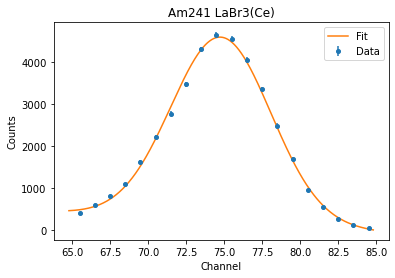

In [273]:
counts_listam241 = []
countserr_listam241 = []
mu_listam241 = []
muerr_listam241 = []
sigma_listam241 = []
sigmaerr_listam241 = []

peak_channel_guess = channels_am241[0] 
fit_width = 10   

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelsam241 >= xmin) & (channelsam241 <= xmax)

x = channelsam241[mask]
y = netcountsam241[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countsam241[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countsam241[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listam241.append(A)
countserr_listam241.append(A_err)
print(counts_listam241)
mu_listam241.append(mu)
muerr_listam241.append(mu_err)
print(mu_listam241)
sigma_listam241.append(sigma)
sigmaerr_listam241.append(sigma_err)
print(sigma_listam241)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countsam241[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Am241 LaBr3(Ce)")

plt.legend()
plt.show()

### Co60

Counts (A): 9275.82 ± 154.35
Mean (mu): 1512.37 ± 0.22
Sigma: 15.47 ± 0.23
Background linear (B): -0.2561 ± 0.0226
Background constant (c): 401.38 ± 34.64

Reduced chi²: 1.3057711964
P-value: 0.024330969122712
[9275.823434138461]
[1512.3697402583655]
[15.46851662793983]


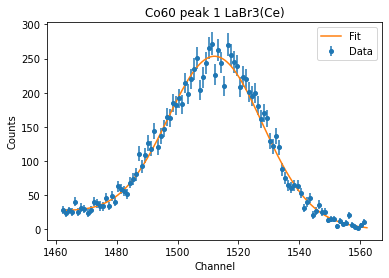

In [274]:
counts_listco60 = [] 
countserr_listco60 = []
mu_listco60 = []
muerr_listco60 = []
sigma_listco60 = []
sigmaerr_listco60 = []

peak_channel_guess = channels_co60[0] 
fit_width = 50

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelsco60 >= xmin) & (channelsco60 <= xmax)

x = channelsco60[mask]
y = netcountsco60[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countsco60[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countsco60[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listco60.append(A)
countserr_listco60.append(A_err)
print(counts_listco60)
mu_listco60.append(mu)
muerr_listco60.append(mu_err)
print(mu_listco60)
sigma_listco60.append(sigma)
sigmaerr_listco60.append(sigma_err)
print(sigma_listco60)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countsco60[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Co60 peak 1 LaBr3(Ce)")

plt.legend()
plt.show()

Counts (A): 8226.74 ± 170.31
Mean (mu): 1714.31 ± 0.26
Sigma: 16.78 ± 0.30
Background linear (B): -0.2024 ± 0.0235
Background constant (c): 348.88 ± 41.25

Reduced chi²: 1.0194766871
P-value: 0.429662006551816
[9275.823434138461, 8226.740482043147]
[1512.3697402583655, 1714.311587380042]
[15.46851662793983, 16.7838718603907]


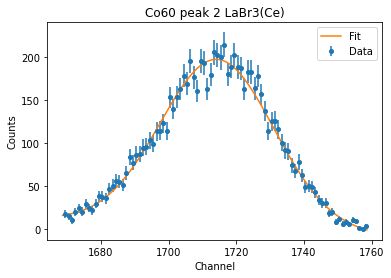

In [275]:
peak_channel_guess = channels_co60[1] 
fit_width = 45   

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelsco60 >= xmin) & (channelsco60 <= xmax)

x = channelsco60[mask]
y = netcountsco60[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countsco60[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countsco60[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listco60.append(A)
counts_listco60[1] = A
countserr_listco60.append(A_err)
countserr_listco60[1] = A_err
print(counts_listco60)
mu_listco60.append(mu)
mu_listco60[1] = mu
muerr_listco60.append(mu_err)
muerr_listco60[1] = mu_err
print(mu_listco60)
sigma_listco60.append(sigma)
sigma_listco60[1] = sigma
sigmaerr_listco60.append(sigma_err)
sigmaerr_listco60[1] = sigma_err
print(sigma_listco60)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countsco60[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Co60 peak 2 LaBr3(Ce)")

plt.legend()
plt.show()

### Cs137

Counts (A): 15028.74 ± 146.38
Mean (mu): 861.76 ± 0.10
Sigma: 10.80 ± 0.10
Background linear (B): -0.2529 ± 0.0276
Background constant (c): 225.88 ± 24.29

Reduced chi²: 1.1067674601
P-value: 0.246389524749827
[15028.741005949665]
[861.761431413889]
[10.797706623623366]


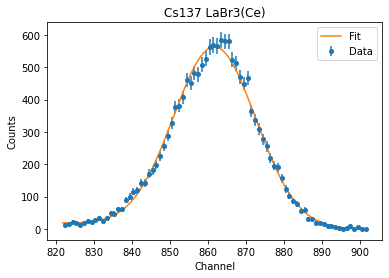

In [276]:
counts_listcs137 = [] 
countserr_listcs137 = []
mu_listcs137 = []
muerr_listcs137 = []
sigma_listcs137 = []
sigmaerr_listcs137 = []

peak_channel_guess = channels_cs137[0] 
fit_width = 40 

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelscs137 >= xmin) & (channelscs137 <= xmax)

x = channelscs137[mask]
y = netcountscs137[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countscs137[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countscs137[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listcs137.append(A)
countserr_listcs137.append(A_err)
print(counts_listcs137)
mu_listcs137.append(mu)
muerr_listcs137.append(mu_err)
print(mu_listcs137)
sigma_listcs137.append(sigma)
sigmaerr_listcs137.append(sigma_err)
print(sigma_listcs137)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countscs137[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Cs137 LaBr3(Ce)")

plt.legend()
plt.show()

### Eu152

Counts (A): 14307.59 ± 206.03
Mean (mu): 157.37 ± 0.06
Sigma: 4.51 ± 0.06
Background linear (B): -4.2324 ± 0.3047
Background constant (c): 924.65 ± 48.81

Reduced chi²: 1.1236081708
P-value: 0.282239147169600
[14307.585763842948]
[157.37454077483423]
[4.509286798260042]


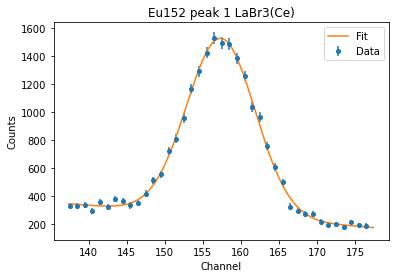

In [277]:
counts_listeu152 = [] 
countserr_listeu152 = []
mu_listeu152 = []
muerr_listeu152 = []
sigma_listeu152 = []
sigmaerr_listeu152 = []

peak_channel_guess = channels_eu152[0] 
fit_width = 20

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelseu152 >= xmin) & (channelseu152 <= xmax)

x = channelseu152[mask]
y = netcountseu152[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countseu152[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countseu152[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listeu152.append(A)
countserr_listeu152.append(A_err)
print(counts_listeu152)
mu_listeu152.append(mu)
muerr_listeu152.append(mu_err)
print(mu_listeu152)
sigma_listeu152.append(sigma)
sigmaerr_listeu152.append(sigma_err)
print(sigma_listeu152)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countseu152[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Eu152 peak 1 LaBr3(Ce)")

plt.legend()
plt.show()

Counts (A): 2853.92 ± 113.99
Mean (mu): 317.88 ± 0.24
Sigma: 6.25 ± 0.25
Background linear (B): -0.7545 ± 0.0645
Background constant (c): 352.19 ± 20.96

Reduced chi²: 0.9742122788
P-value: 0.541697017486129
[14307.585763842948, 2853.9200550435553]
[157.37454077483423, 317.8804341212993]
[4.509286798260042, 6.252854588818531]


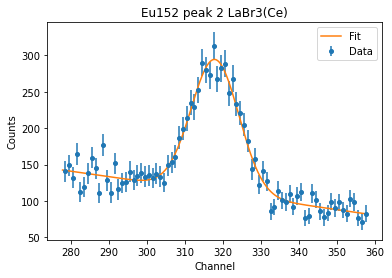

In [278]:
peak_channel_guess = channels_eu152[1] 
fit_width = 40

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelseu152 >= xmin) & (channelseu152 <= xmax)

x = channelseu152[mask]
y = netcountseu152[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countseu152[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countseu152[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listeu152.append(A)
counts_listeu152[1] = A
countserr_listeu152.append(A_err)
countserr_listeu152[1] = A_err
print(counts_listeu152)
mu_listeu152.append(mu)
mu_listeu152[1] = mu
muerr_listeu152.append(mu_err)
muerr_listeu152[1] = mu_err
print(mu_listeu152)
sigma_listeu152.append(sigma)
sigma_listeu152[1] = sigma
sigmaerr_listeu152.append(sigma_err)
sigmaerr_listeu152[1] = sigma_err
print(sigma_listeu152)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countseu152[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Eu152 peak 2 LaBr3(Ce)")

plt.legend()
plt.show()

Counts (A): 8054.69 ± 125.51
Mean (mu): 446.76 ± 0.12
Sigma: 7.56 ± 0.11
Background linear (B): -0.2925 ± 0.0465
Background constant (c): 185.31 ± 21.06

Reduced chi²: 1.0562455737
P-value: 0.347382720903754
[14307.585763842948, 2853.9200550435553, 8054.68594854896]
[157.37454077483423, 317.8804341212993, 446.76026670479445]
[4.509286798260042, 6.252854588818531, 7.564753863580342]


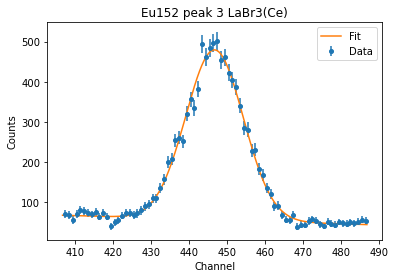

In [279]:
peak_channel_guess = channels_eu152[2] 
fit_width = 40

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelseu152 >= xmin) & (channelseu152 <= xmax)

x = channelseu152[mask]
y = netcountseu152[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countseu152[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countseu152[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listeu152.append(A)
counts_listeu152[2] = A
countserr_listeu152.append(A_err)
countserr_listeu152[2] = A_err
print(counts_listeu152)
mu_listeu152.append(mu)
mu_listeu152[2] = mu
muerr_listeu152.append(mu_err)
muerr_listeu152[2] = mu_err
print(mu_listeu152)
sigma_listeu152.append(sigma)
sigma_listeu152[2] = sigma
sigmaerr_listeu152.append(sigma_err)
sigmaerr_listeu152[2] = sigma_err
print(sigma_listeu152)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countseu152[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Eu152 peak 3 LaBr3(Ce)")

plt.legend()
plt.show()

Counts (A): 1632.11 ± 64.89
Mean (mu): 1006.66 ± 0.47
Sigma: 11.53 ± 0.47
Background linear (B): -0.0306 ± 0.0067
Background constant (c): 49.64 ± 6.80

Reduced chi²: 1.0437446729
P-value: 0.322956745763305
[14307.585763842948, 2853.9200550435553, 8054.68594854896, 1632.1085303126608]
[157.37454077483423, 317.8804341212993, 446.76026670479445, 1006.6622480098341]
[4.509286798260042, 6.252854588818531, 7.564753863580342, 11.529691060908386]


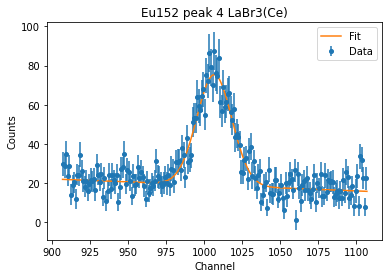

In [280]:
peak_channel_guess = channels_eu152[3] 
fit_width = 100

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelseu152 >= xmin) & (channelseu152 <= xmax)

x = channelseu152[mask]
y = netcountseu152[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countseu152[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countseu152[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listeu152.append(A)
counts_listeu152[3] = A
countserr_listeu152.append(A_err)
countserr_listeu152[3] = A_err
print(counts_listeu152)
mu_listeu152.append(mu)
mu_listeu152[3] = mu
muerr_listeu152.append(mu_err)
muerr_listeu152[3] = mu_err
print(mu_listeu152)
sigma_listeu152.append(sigma)
sigma_listeu152[3] = sigma
sigmaerr_listeu152.append(sigma_err)
sigmaerr_listeu152[3] = sigma_err
print(sigma_listeu152)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countseu152[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Eu152 peak 4 LaBr3(Ce)")

plt.legend()
plt.show()

Counts (A): 1358.84 ± 60.66
Mean (mu): 1242.65 ± 0.57
Sigma: 12.75 ± 0.56
Background linear (B): -0.0299 ± 0.0069
Background constant (c): 46.42 ± 8.66

Reduced chi²: 1.0125416108
P-value: 0.440337593765883
[14307.585763842948, 2853.9200550435553, 8054.68594854896, 1632.1085303126608, 1358.8423551616904]
[157.37454077483423, 317.8804341212993, 446.76026670479445, 1006.6622480098341, 1242.650820985694]
[4.509286798260042, 6.252854588818531, 7.564753863580342, 11.529691060908386, 12.745250229338904]


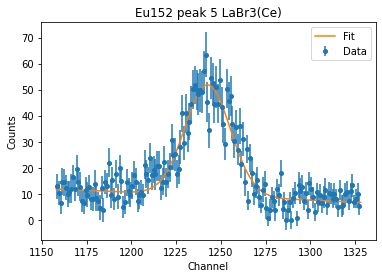

In [281]:
peak_channel_guess = channels_eu152[4] 
fit_width = 85

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelseu152 >= xmin) & (channelseu152 <= xmax)

x = channelseu152[mask]
y = netcountseu152[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countseu152[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countseu152[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listeu152.append(A)
counts_listeu152[4] = A
countserr_listeu152.append(A_err)
countserr_listeu152[4] = A_err
print(counts_listeu152)
mu_listeu152.append(mu)
mu_listeu152[4] = mu
muerr_listeu152.append(mu_err)
muerr_listeu152[4] = mu_err
print(mu_listeu152)
sigma_listeu152.append(sigma)
sigma_listeu152[4] = sigma
sigmaerr_listeu152.append(sigma_err)
sigmaerr_listeu152[4] = sigma_err
print(sigma_listeu152)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countseu152[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Eu152 peak 5 LaBr3(Ce)")

plt.legend()
plt.show()

### Na22

Counts (A): 1038.86 ± 76.34
Mean (mu): 663.29 ± 0.52
Sigma: 9.27 ± 0.58
Background linear (B): -0.0846 ± 0.0374
Background constant (c): 58.00 ± 24.83

Reduced chi²: 0.7953150991
P-value: 0.862596116887920
[1038.8630261028622]
[663.2901962690584]
[9.268349232366727]


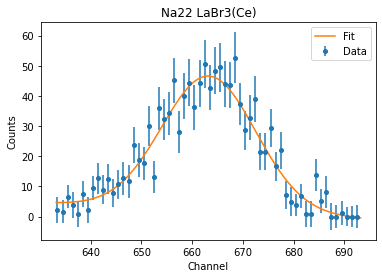

In [282]:
counts_listna22 = [] 
countserr_listna22 = []
mu_listna22 = []
muerr_listna22 = []
sigma_listna22 = []
sigmaerr_listna22 = []

peak_channel_guess = channels_na22[0] 
fit_width = 30

xmin = peak_channel_guess - fit_width
xmax = peak_channel_guess + fit_width

mask = (channelsna22 >= xmin) & (channelsna22 <= xmax)

x = channelsna22[mask]
y = netcountsna22[mask]

A_guess = np.sum(y)
mu_guess = peak_channel_guess
sigma_guess = 10
B_guess = 0
c_guess = np.min(y)

p0 = [A_guess, mu_guess, sigma_guess, B_guess, c_guess]

popt, pcov = curve_fit(
    model,
    x,
    y,
    p0=p0,
    sigma=sigma_countsna22[mask],
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, mu, sigma, B, c = popt
A_err, mu_err, sigma_err, B_err, c_err = perr

y_fit = model(x, *popt)

chi2_val = np.sum(((y - y_fit)/sigma_countsna22[mask])**2)
ndof = len(x) - len(popt)

chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

print(f"Counts (A): {A:.2f} ± {A_err:.2f}")
print(f"Mean (mu): {mu:.2f} ± {mu_err:.2f}")
print(f"Sigma: {sigma:.2f} ± {sigma_err:.2f}")

print(f"Background linear (B): {B:.4f} ± {B_err:.4f}")
print(f"Background constant (c): {c:.2f} ± {c_err:.2f}")

print()
print(f"Reduced chi²: {chi2_red:.10f}")
print(f"P-value: {p_value:.15f}")

counts_listna22.append(A)
countserr_listna22.append(A_err)
print(counts_listna22)
mu_listna22.append(mu)
muerr_listna22.append(mu_err)
print(mu_listna22)
sigma_listna22.append(sigma)
sigmaerr_listna22.append(sigma_err)
print(sigma_listna22)

x_plot = np.linspace(xmin, xmax, 1000)

plt.errorbar(x, y, yerr=sigma_countsna22[mask], fmt='o', label="Data", markersize=4)
plt.plot(x_plot, model(x_plot, *popt), label="Fit")

plt.xlabel("Channel")
plt.ylabel("Counts")
plt.title("Na22 LaBr3(Ce)")

plt.legend()
plt.show()

---

# Energy calibration 

In [283]:
mu_list = mu_listam241 + mu_listco60 + mu_listcs137 + mu_listeu152 + mu_listna22
mu_err_list = muerr_listam241 + muerr_listco60 + muerr_listcs137 + muerr_listeu152 + muerr_listna22
sigma_list = sigma_listam241 + sigma_listco60 + sigma_listcs137 + sigma_listeu152 + sigma_listna22
sigma_err_list = sigmaerr_listam241 + sigmaerr_listco60 + sigmaerr_listcs137 + sigmaerr_listeu152 + sigmaerr_listna22
energy_list = energies_am241 + energies_co60 + energies_cs137 + energies_eu152 + energies_na22

print(len(mu_list))
print(len(sigma_list))
print(len(energy_list))

10
10
10


In [284]:
mu_array = np.array(mu_list)
mu_err_array = np.array(mu_err_list)
sigma_array = np.array(sigma_list)
sigma_err_array = np.array(sigma_err_list)
energy_array = np.array(energy_list)

### linear fit

In [285]:
def energy_calib_linear(x, A, B):
    return A*x + B

Calibration results:
A = 7.710360e-01 ± 1.971023e-03
B = 1.526021e+00 ± 5.937164e-01


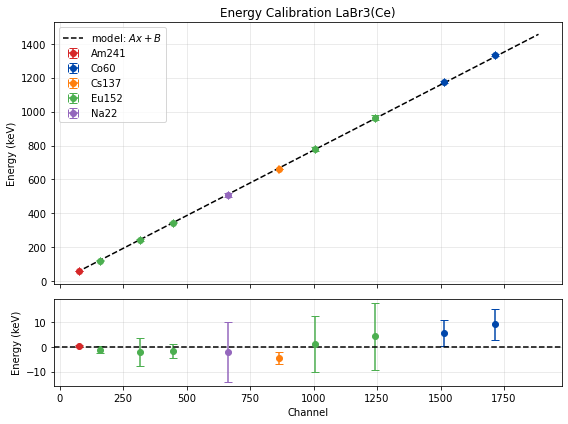

Before rescaling:
Reduced chi²: 931.940
P-value: 0.0000

After rescaling:
Reduced chi²: 1.000
P-value: 0.4335


In [349]:
# initial guess
p0 = [1, 2]

# temporary fit (needed to estimate sigma_E)
popt_temp, _ = curve_fit(energy_calib_linear, mu_array, energy_array, p0=p0)

A_temp, B_temp = popt_temp

# propagate errors
sigma_E = np.abs(A_temp) * mu_err_array

# avoid zeros
sigma_E[sigma_E == 0] = 1

# FIRST FIT
popt, pcov = curve_fit(
    energy_calib_linear,
    mu_array,
    energy_array,
    sigma=sigma_E,
    absolute_sigma=True
)

# compute chi2 with initial uncertainties
E_fit_initial = energy_calib_linear(mu_array, *popt)
chi2_val_initial = np.sum(((energy_array - E_fit_initial)/sigma_E)**2)
ndof = len(mu_array) - len(popt)
chi2_red_initial = chi2_val_initial / ndof
p_value_initial = 1 - chi2.cdf(chi2_val_initial, ndof)

# rescale uncertainties 
scale_factor = np.sqrt(chi2_red_initial)
sigma_E_scaled = sigma_E * scale_factor

# FINAL FIT
popt, pcov = curve_fit(
    energy_calib_linear,
    mu_array,
    energy_array,
    sigma=sigma_E_scaled,
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, B = popt
A_err, B_err = perr

print("Calibration results:")
print(f"A = {A:.6e} ± {A_err:.6e}")
print(f"B = {B:.6e} ± {B_err:.6e}")

residuals = energy_array - energy_calib_linear(mu_array, *popt)

E_fit = energy_calib_linear(mu_array, *popt)
chi2_val = np.sum(((energy_array - E_fit)/sigma_E_scaled)**2)
ndof = len(mu_array) - len(popt)
chi2_red = chi2_val / ndof

p_value = 1 - chi2.cdf(chi2_val, ndof)

fig, (ax_main, ax_resid) = plt.subplots(2, 1, 
                                        sharex=True,
                                        gridspec_kw={'height_ratios':[3,1]},
                                        figsize=(8,6))

# --- Main plot ---
x_plot = np.linspace(min(mu_array)*0.9, max(mu_array)*1.1, 500)
ax_main.errorbar(mu_array[0], energy_array[0], xerr=mu_err_array[0], yerr=sigma_E_scaled[0], fmt='o', color='#d62728', label='Am241', capsize=4)
ax_main.errorbar(mu_array[1:3], energy_array[1:3], xerr=mu_err_array[1:3], yerr=sigma_E_scaled[1:3], fmt='o', color='#0047AB', label='Co60', capsize=4)
ax_main.errorbar(mu_array[3], energy_array[3], xerr=mu_err_array[3], yerr=sigma_E_scaled[3], fmt='o', color='#ff7f0e', label='Cs137', capsize=4)
ax_main.errorbar(mu_array[4:9], energy_array[4:9], xerr=mu_err_array[4:9], yerr=sigma_E_scaled[4:9], fmt='o', color='#4CAF50', label='Eu152', capsize=4)
ax_main.errorbar(mu_array[9], energy_array[9], xerr=mu_err_array[9], yerr=sigma_E_scaled[9], fmt='o', color='#9467bd', label='Na22', capsize=4)
ax_main.plot(x_plot, energy_calib_linear(x_plot, *popt), 'k--', label=r'model: $Ax + B$')
ax_main.set_ylabel("Energy (keV)")
ax_main.legend()
ax_main.set_title("Energy Calibration LaBr3(Ce)")
ax_main.grid(True, alpha=0.3)


# --- Residuals plot ---
ax_resid.errorbar(mu_array[0], residuals[0], yerr=sigma_E_scaled[0], color='#d62728', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[1:3], residuals[1:3], yerr=sigma_E_scaled[1:3], color='#0047AB', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[3], residuals[3], yerr=sigma_E_scaled[3], color='#ff7f0e', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[4:9], residuals[4:9], yerr=sigma_E_scaled[4:9], color='#4CAF50', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[9], residuals[9], yerr=sigma_E_scaled[9], color='#9467bd', fmt='o', capsize=4)
ax_resid.axhline(0, color='black', linestyle='--')
ax_resid.set_xlabel("Channel")
ax_resid.set_ylabel("Energy (keV)")
ax_resid.grid(True, alpha=0.3)


plt.tight_layout()
plt.show()

print("Before rescaling:")
print(f"Reduced chi²: {chi2_red_initial:.3f}")
print(f"P-value: {p_value_initial:.4f}")
print()
print("After rescaling:")
print(f"Reduced chi²: {chi2_red:.3f}")
print(f"P-value: {p_value:.4f}")

### quadratic fit

In [314]:
def energy_calib(x, A, B, C):
    return A*x**2 + B*x + C

Calibration results:
A = 1.192833e-05 ± 1.484376e-06
B = 7.553068e-01 ± 2.053515e-03
C = 2.966995e+00 ± 2.633475e-01


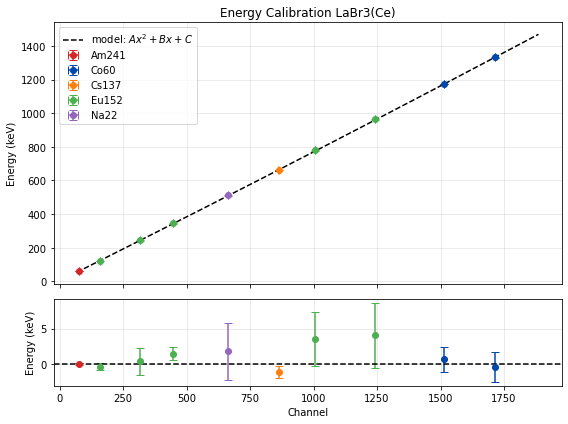

Before rescaling:
Reduced chi²: 103.256
P-value: 0.0000

After rescaling:
Reduced chi²: 1.000
P-value: 0.4289


In [348]:
# initial guess
p0 = [0, 1, 2]

# temporary fit (needed to estimate sigma_E)
popt_temp, _ = curve_fit(energy_calib, mu_array, energy_array, p0=p0)

A_temp, B_temp, C_temp = popt_temp

# propagate errors
sigma_E = np.abs(2*A_temp*mu_array + B_temp) * mu_err_array

# avoid zeros
sigma_E[sigma_E == 0] = 1

# FIRST FIT
popt, pcov = curve_fit(
    energy_calib,
    mu_array,
    energy_array,
    sigma=sigma_E,
    absolute_sigma=True
)

# compute chi2 with initial uncertainties
E_fit_initial = energy_calib(mu_array, *popt)
chi2_val_initial = np.sum(((energy_array - E_fit_initial)/sigma_E)**2)
ndof = len(mu_array) - len(popt)
chi2_red_initial = chi2_val_initial / ndof

p_value_initial = 1 - chi2.cdf(chi2_val_initial, ndof)

# rescale uncertainties
scale_factor = np.sqrt(chi2_red_initial)
sigma_E_scaled = sigma_E * scale_factor

# FINAL FIT
popt, pcov = curve_fit(
    energy_calib,
    mu_array,
    energy_array,
    sigma=sigma_E_scaled,
    absolute_sigma=True
)

perr = np.sqrt(np.diag(pcov))

A, B, C = popt
A_err, B_err, C_err = perr

print("Calibration results:")
print(f"A = {A:.6e} ± {A_err:.6e}")
print(f"B = {B:.6e} ± {B_err:.6e}")
print(f"C = {C:.6e} ± {C_err:.6e}")

residuals = energy_array - energy_calib(mu_array, *popt)

E_fit = energy_calib(mu_array, *popt)

chi2_val = np.sum(((energy_array - E_fit)/sigma_E_scaled)**2)
ndof = len(mu_array) - len(popt)
chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

fig, (ax_main, ax_resid) = plt.subplots(2, 1, 
                                        sharex=True,
                                        gridspec_kw={'height_ratios':[3,1]},
                                        figsize=(8,6))

# --- Main plot ---
x_plot = np.linspace(min(mu_array)*0.9, max(mu_array)*1.1, 500)
ax_main.errorbar(mu_array[0], energy_array[0], xerr=mu_err_array[0], yerr=sigma_E_scaled[0], fmt='o', color='#d62728', label='Am241', capsize=4)
ax_main.errorbar(mu_array[1:3], energy_array[1:3], xerr=mu_err_array[1:3], yerr=sigma_E_scaled[1:3], fmt='o', color='#0047AB', label='Co60', capsize=4)
ax_main.errorbar(mu_array[3], energy_array[3], xerr=mu_err_array[3], yerr=sigma_E_scaled[3], fmt='o', color='#ff7f0e', label='Cs137', capsize=4)
ax_main.errorbar(mu_array[4:9], energy_array[4:9], xerr=mu_err_array[4:9], yerr=sigma_E_scaled[4:9], fmt='o', color='#4CAF50', label='Eu152', capsize=4)
ax_main.errorbar(mu_array[9], energy_array[9], xerr=mu_err_array[9], yerr=sigma_E_scaled[9], fmt='o', color='#9467bd', label='Na22', capsize=4)
ax_main.plot(x_plot, energy_calib(x_plot, *popt), 'k--', label=r'model: $Ax^2 + Bx + C$')
ax_main.set_ylabel("Energy (keV)")
ax_main.legend()
ax_main.set_title("Energy Calibration LaBr3(Ce)")
ax_main.grid(True, alpha=0.3)



# --- Residuals plot ---
ax_resid.errorbar(mu_array[0], residuals[0], yerr=sigma_E_scaled[0], color='#d62728', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[1:3], residuals[1:3], yerr=sigma_E_scaled[1:3], color='#0047AB', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[3], residuals[3], yerr=sigma_E_scaled[3], color='#ff7f0e', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[4:9], residuals[4:9], yerr=sigma_E_scaled[4:9], color='#4CAF50', fmt='o', capsize=4)
ax_resid.errorbar(mu_array[9], residuals[9], yerr=sigma_E_scaled[9], color='#9467bd', fmt='o', capsize=4)
ax_resid.axhline(0, color='black', linestyle='--')
ax_resid.set_xlabel("Channel")
ax_resid.set_ylabel("Energy (keV)")
ax_resid.grid(True, alpha=0.3)



plt.tight_layout()
plt.show()

print("Before rescaling:")
print(f"Reduced chi²: {chi2_red_initial:.3f}")
print(f"P-value: {p_value_initial:.4f}")
print()
print("After rescaling:")
print(f"Reduced chi²: {chi2_red:.3f}")
print(f"P-value: {p_value:.4f}")

---

# Resolution

energy resolution: R(E) = FWHM/E , FWHM = 2.355 * sigma

sigma_E = |dE/dx| * sigma

E(x) = Ax² + Bx + C

dE/dx = 2Ax + B

In [324]:
print(2*np.sqrt(2*np.log(2)))

2.3548200450309493


In [334]:
dEdx = 2*A*mu_array + B

sigma_E = np.abs(dEdx) * sigma_array
FWHM_E = 2*np.sqrt(2*np.log(2)) * sigma_E

resolution = FWHM_E / energy_array

In [341]:
error_sigma = (dEdx * sigma_err_array)**2
error_mu = (2*A*sigma_array * mu_err_array)**2
error_A = (2*mu_array*sigma_array * A_err)**2
error_B = (sigma_array * B_err)**2

sigma_E_err = np.sqrt(error_sigma+error_mu+error_A+error_B)

In [342]:
FWHM_E_err = 2*np.sqrt(2*np.log(2)) * sigma_E_err

resolution_err = FWHM_E_err / energy_array

In [355]:
def resolution_model(E, A, B, C):
    return A/E + B/np.sqrt(E) + C

A = 1.7495e+00 ± 2.6663e-01
B = 4.6305e-01 ± 4.0281e-02
C = 9.3204e-03 ± 1.1215e-03


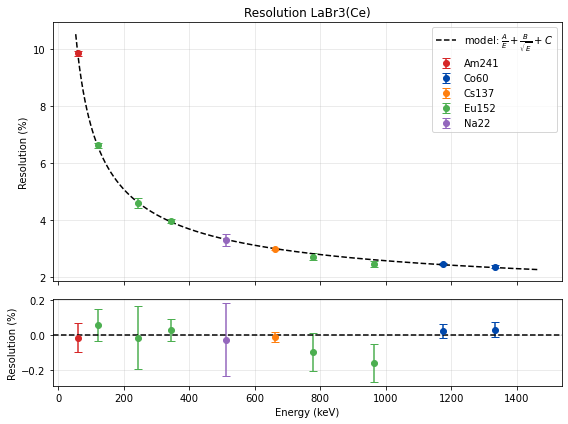

Reduced chi²: 0.674
P-value: 0.6947


In [356]:
# Fit the resolution
p0 = [1,1,0]
popt, pcov = curve_fit(
    resolution_model,
    energy_array,
    resolution,
    sigma=resolution_err,
    absolute_sigma=True
)
perr = np.sqrt(np.diag(pcov))
A_res, B_res, C_res = popt

# Residuals
residuals = resolution - resolution_model(energy_array, *popt)

# --- Compute reduced chi² and p-value ---
chi2_val = np.sum((residuals / resolution_err)**2)
ndof = len(energy_array) - len(popt)
chi2_red = chi2_val / ndof
p_value = 1 - chi2.cdf(chi2_val, ndof)

# --- Plotting ---
fig, (ax_main, ax_resid) = plt.subplots(
    2, 1,
    sharex=True,
    gridspec_kw={'height_ratios':[3,1]},
    figsize=(8,6)
)

print(f"A = {A_res:.4e} ± {perr[0]:.4e}")
print(f"B = {B_res:.4e} ± {perr[1]:.4e}")
print(f"C = {C_res:.4e} ± {perr[2]:.4e}")

# --- Main plot ---
E_plot = np.linspace(min(energy_array)*0.9, max(energy_array)*1.1, 500)

ax_main.errorbar(energy_array[0], resolution[0]*100, yerr=resolution_err[0]*100, fmt='o', color='#d62728', label='Am241', capsize=4)
ax_main.errorbar(energy_array[1:3], resolution[1:3]*100, yerr=resolution_err[1:3]*100, fmt='o', color='#0047AB', label='Co60', capsize=4)
ax_main.errorbar(energy_array[3], resolution[3]*100, yerr=resolution_err[3]*100, fmt='o', color='#ff7f0e', label='Cs137', capsize=4)
ax_main.errorbar(energy_array[4:9], resolution[4:9]*100, yerr=resolution_err[4:9]*100, fmt='o', color='#4CAF50', label='Eu152', capsize=4)
ax_main.errorbar(energy_array[9], resolution[9]*100, yerr=resolution_err[9]*100, fmt='o', color='#9467bd', label='Na22', capsize=4)
ax_main.plot(E_plot, resolution_model(E_plot, *popt)*100, 'k--', label=r'model: $\frac{A}{E} + \frac{B}{\sqrt{E}} + C$')
ax_main.set_ylabel("Resolution (%)")
ax_main.set_title("Resolution LaBr3(Ce)")
ax_main.legend()
ax_main.grid(True, alpha=0.3)

ax_resid.errorbar(energy_array[0], residuals[0]*100, yerr=resolution_err[0]*100, fmt='o', color='#d62728', capsize=4)
ax_resid.errorbar(energy_array[1:3], residuals[1:3]*100, yerr=resolution_err[1:3]*100, fmt='o', color='#0047AB', capsize=4)
ax_resid.errorbar(energy_array[3], residuals[3]*100, yerr=resolution_err[3]*100, fmt='o', color='#ff7f0e', capsize=4)
ax_resid.errorbar(energy_array[4:9], residuals[4:9]*100, yerr=resolution_err[4:9]*100, fmt='o', color='#4CAF50', capsize=4)
ax_resid.errorbar(energy_array[9], residuals[9]*100, yerr=resolution_err[9]*100, fmt='o', color='#9467bd', capsize=4)
ax_resid.axhline(0, color='black', linestyle='--')
ax_resid.set_xlabel("Energy (keV)")
ax_resid.set_ylabel("Resolution (%)")
ax_resid.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Reduced chi²: {chi2_red:.3f}")
print(f"P-value: {p_value:.4f}")

---

# Absolute efficiency